# Overfitting and Underfitting in Machine Learning

This notebook explores the concepts of overfitting and underfitting in machine learning models, demonstrating how to identify these issues and implement techniques to address them.

## 1. Import Required Libraries

In [6]:
# # Import necessary libraries
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.model_selection import train_test_split, learning_curve, cross_val_score
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LinearRegression, Ridge, Lasso
# from sklearn.preprocessing import PolynomialFeatures
# from sklearn.pipeline import Pipeline
# from sklearn.metrics import mean_squared_error, r2_score
# from sklearn.datasets import load_boston, load_diabetes
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.svm import SVR

# # Set random seed for reproducibility
# np.random.seed(42)

# # Set visualization styles
# plt.style.use('seaborn-v0_8-whitegrid')
# sns.set_theme(style="whitegrid")

```
ImportError: 
`load_boston` has been removed from scikit-learn since version 1.2.

The Boston housing prices dataset has an ethical problem: as
investigated in [1], the authors of this dataset engineered a
non-invertible variable "B" assuming that racial self-segregation had a
positive impact on house prices [2]. Furthermore the goal of the
research that led to the creation of this dataset was to study the
impact of air quality but it did not give adequate demonstration of the
validity of this assumption.

The scikit-learn maintainers therefore strongly discourage the use of
this dataset unless the purpose of the code is to study and educate
about ethical issues in data science and machine learning.

In this special case, you can fetch the dataset from the original
source::

    import pandas as pd
    import numpy as np

    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
    target = raw_df.values[1::2, 2]

Alternative datasets include the California housing dataset and the
Ames housing dataset. You can load the datasets as follows::

    from sklearn.datasets import fetch_california_housing
    housing = fetch_california_housing()

for the California housing dataset and::

    from sklearn.datasets import fetch_openml
    housing = fetch_openml(name="house_prices", as_frame=True)

for the Ames housing dataset.

[1] M Carlisle.
"Racist data destruction?"
<https://medium.com/@docintangible/racist-data-destruction-113e3eff54a8>

[2] Harrison Jr, David, and Daniel L. Rubinfeld.
"Hedonic housing prices and the demand for clean air."
Journal of environmental economics and management 5.1 (1978): 81-102.
<https://www.researchgate.net/publication/4974606_Hedonic_housing_prices_and_the_demand_for_clean_air>
```

In [7]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing, load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Set random seed for reproducibility
np.random.seed(42)

# Set visualization styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style="whitegrid")

# Load California housing dataset as a replacement for the deprecated Boston dataset
housing_data = fetch_california_housing()
X, y = housing_data.data, housing_data.target
feature_names = housing_data

## 2. Understanding Bias-Variance Tradeoff

Overfitting and underfitting represent opposite sides of the bias-variance tradeoff in machine learning:

- **Underfitting (High Bias)**: When a model is too simple to capture the underlying pattern of the data.
  - The model has high bias and low variance
  - It performs poorly on both training and test data
  - Example: Using a linear model for non-linear data

- **Overfitting (High Variance)**: When a model learns the training data too well, including noise and outliers.
  - The model has low bias but high variance
  - It performs extremely well on training data but poorly on test data
  - Example: A high-degree polynomial fitting every point in the training data

The goal is to find the sweet spot where the model is complex enough to learn the true pattern but simple enough to generalize well to unseen data.

## 3. Creating Synthetic Dataset

Let's create a synthetic dataset with a non-linear pattern and some noise to demonstrate underfitting and overfitting.

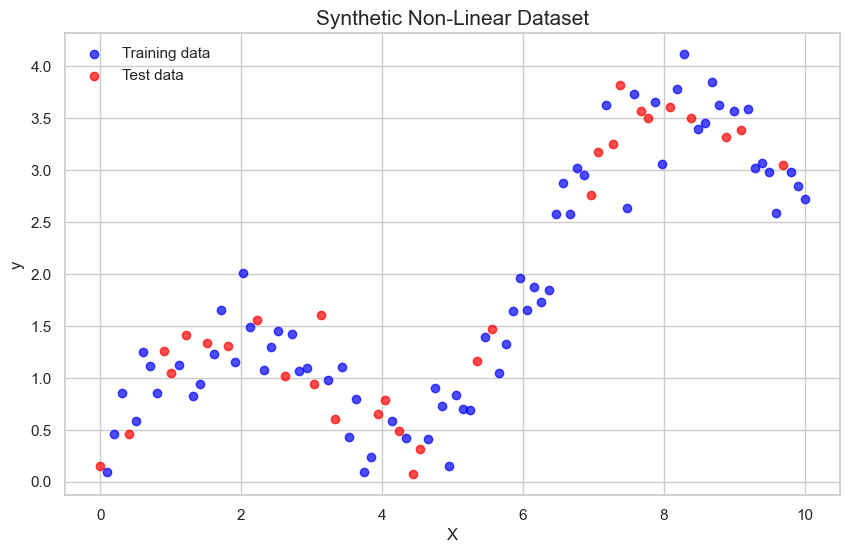

In [8]:
# Generate synthetic data with non-linear pattern
def generate_non_linear_data(n_samples=100, noise=0.3):
    X = np.linspace(0, 10, n_samples).reshape(-1, 1)
    y = np.sin(X.ravel()) + X.ravel()/3 + np.random.normal(0, noise, n_samples)
    return X, y

X, y = generate_non_linear_data(n_samples=100, noise=0.3)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Visualize the data
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', alpha=0.7, label='Training data')
plt.scatter(X_test, y_test, color='red', alpha=0.7, label='Test data')
plt.title('Synthetic Non-Linear Dataset', fontsize=15)
plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.legend()
plt.show()

## 4. Visualizing Underfitting

Let's demonstrate underfitting by using a simple linear regression model on our non-linear data.

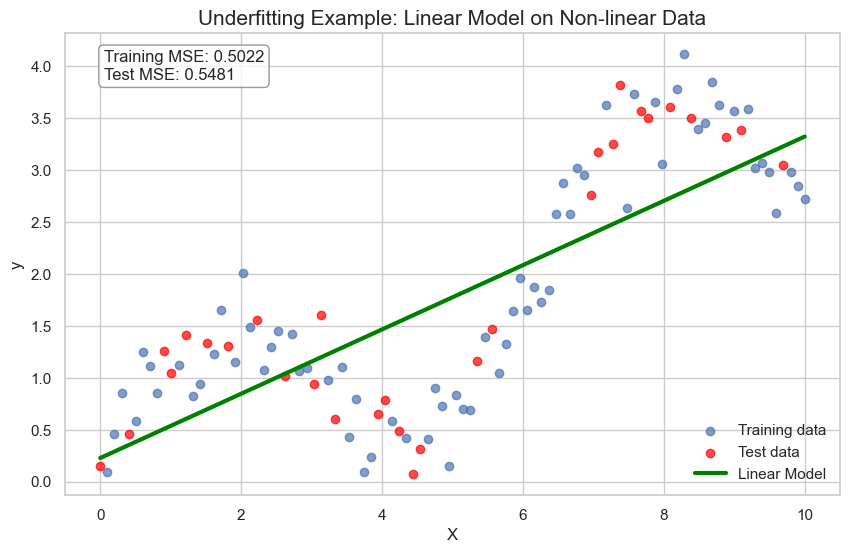

In [9]:
# Create a linear regression model (underfitting example)
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

# Generate predictions for visualization
X_plot = np.linspace(0, 10, 100).reshape(-1, 1)
y_lin_pred = lin_model.predict(X_plot)

# Calculate metrics
train_error = mean_squared_error(y_train, lin_model.predict(X_train))
test_error = mean_squared_error(y_test, lin_model.predict(X_test))

# Plot the data and model prediction
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, alpha=0.7, label='Training data')
plt.scatter(X_test, y_test, alpha=0.7, label='Test data', color='red')
plt.plot(X_plot, y_lin_pred, color='green', linewidth=3, label='Linear Model')
plt.title('Underfitting Example: Linear Model on Non-linear Data', fontsize=15)
plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.legend()
plt.annotate(f'Training MSE: {train_error:.4f}\nTest MSE: {test_error:.4f}', 
             xy=(0.05, 0.9), xycoords='axes fraction', 
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
plt.show()

**Explanation of Underfitting**:

The linear model (straight line) clearly fails to capture the non-linear pattern in our data. This is a classic example of underfitting:

1. The model is too simple (high bias)
2. It makes systematic errors across the entire range
3. Both training and test errors are high
4. Adding more training data won't help significantly improve this model

Underfitting occurs when your model lacks the flexibility to capture the underlying pattern in the data.

## 5. Visualizing Overfitting

Now, let's demonstrate overfitting by using a polynomial regression model with a very high degree.

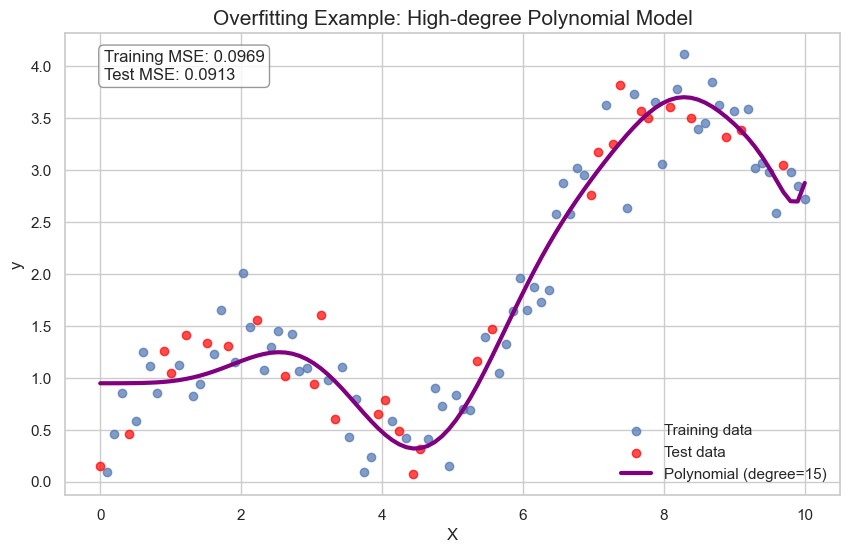

In [10]:
# Function to create polynomial model with specified degree
def create_poly_model(degree):
    return Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('linear', LinearRegression())
    ])

# Create and train high-degree polynomial model (overfitting example)
high_degree = 15
overfit_model = create_poly_model(high_degree)
overfit_model.fit(X_train, y_train)

# Generate predictions
y_overfit_train_pred = overfit_model.predict(X_train)
y_overfit_test_pred = overfit_model.predict(X_test)
y_overfit_plot_pred = overfit_model.predict(X_plot)

# Calculate metrics
train_error = mean_squared_error(y_train, y_overfit_train_pred)
test_error = mean_squared_error(y_test, y_overfit_test_pred)

# Plot the data and model prediction
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, alpha=0.7, label='Training data')
plt.scatter(X_test, y_test, alpha=0.7, label='Test data', color='red')
plt.plot(X_plot, y_overfit_plot_pred, color='purple', linewidth=3, label=f'Polynomial (degree={high_degree})')
plt.title('Overfitting Example: High-degree Polynomial Model', fontsize=15)
plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.legend()
plt.annotate(f'Training MSE: {train_error:.4f}\nTest MSE: {test_error:.4f}', 
             xy=(0.05, 0.9), xycoords='axes fraction', 
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
plt.show()

**Explanation of Overfitting**:

The high-degree polynomial model fits the training data almost perfectly but creates a complex, wiggly function that performs poorly on test data. This is overfitting:

1. The model is too complex (high variance)
2. It's capturing noise in the training data rather than just the underlying pattern
3. Training error is very low, but test error is high
4. Adding more training data might help, but reducing model complexity is often more effective

Overfitting occurs when your model is too flexible and starts memorizing the training data instead of learning generalizable patterns.

## 6. Finding the Sweet Spot (Balanced Model)

Let's find an optimal model complexity that balances between underfitting and overfitting.

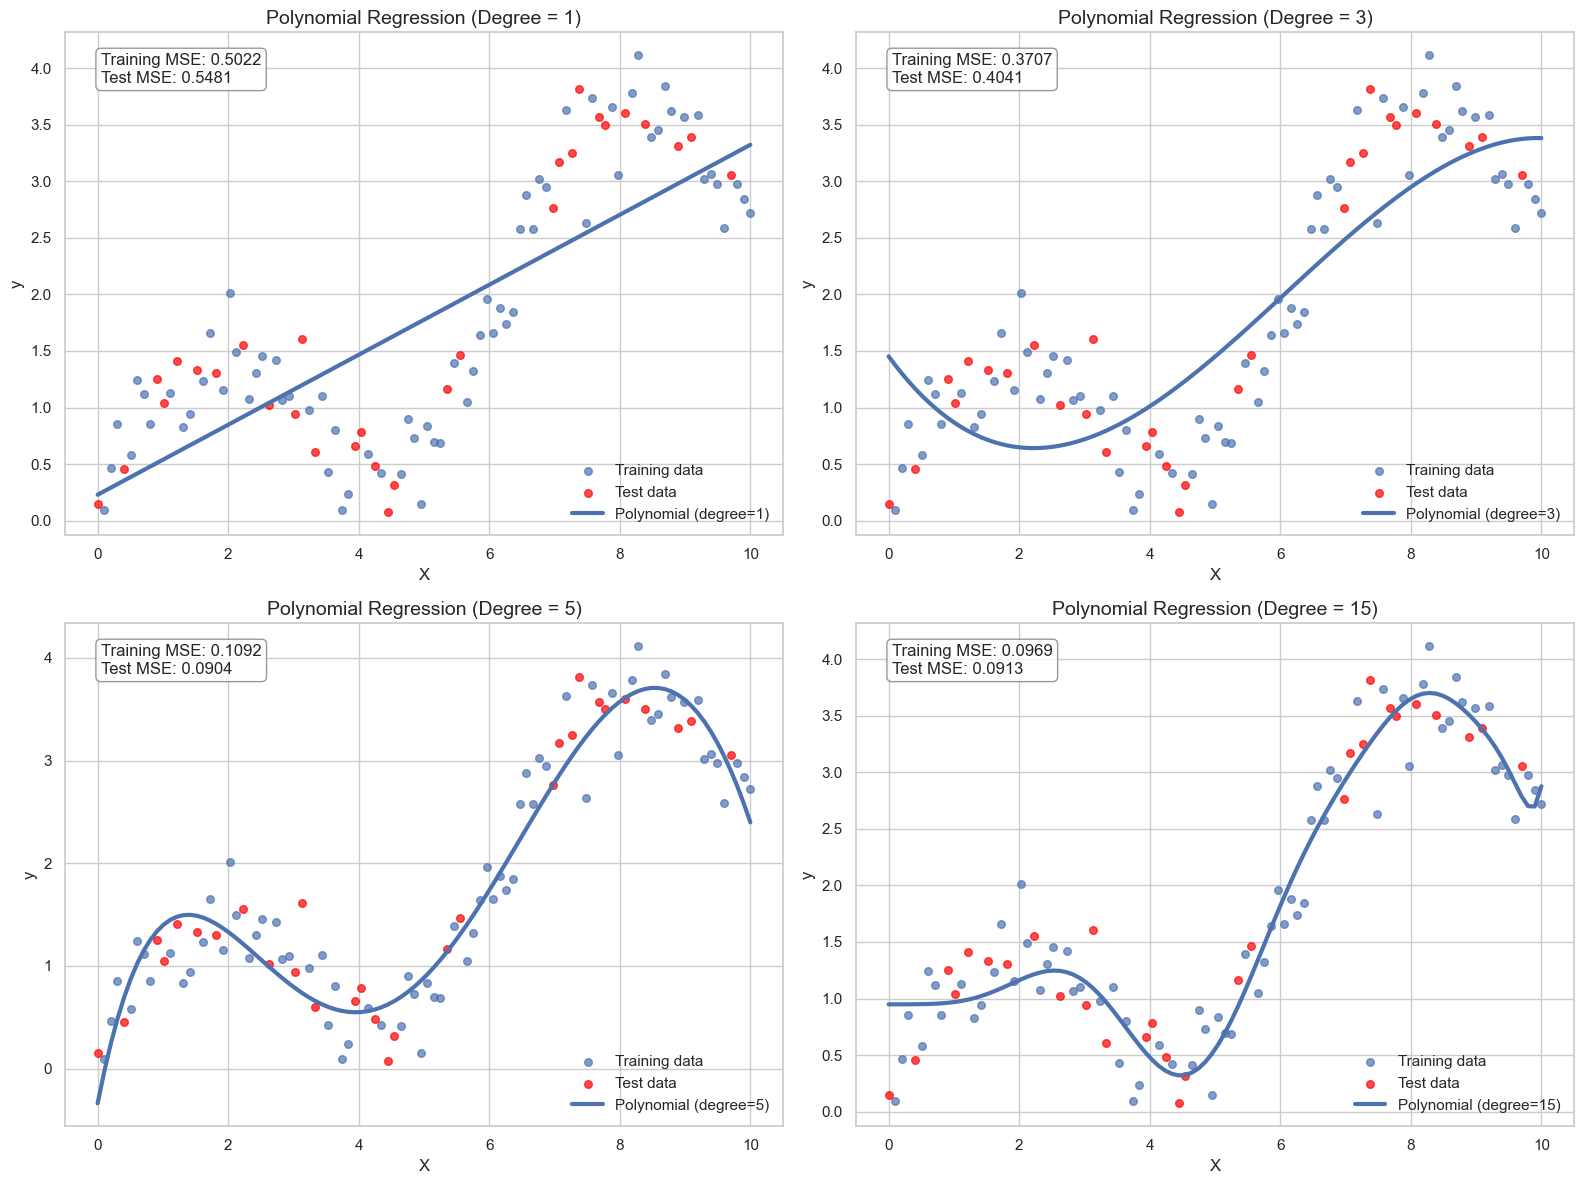

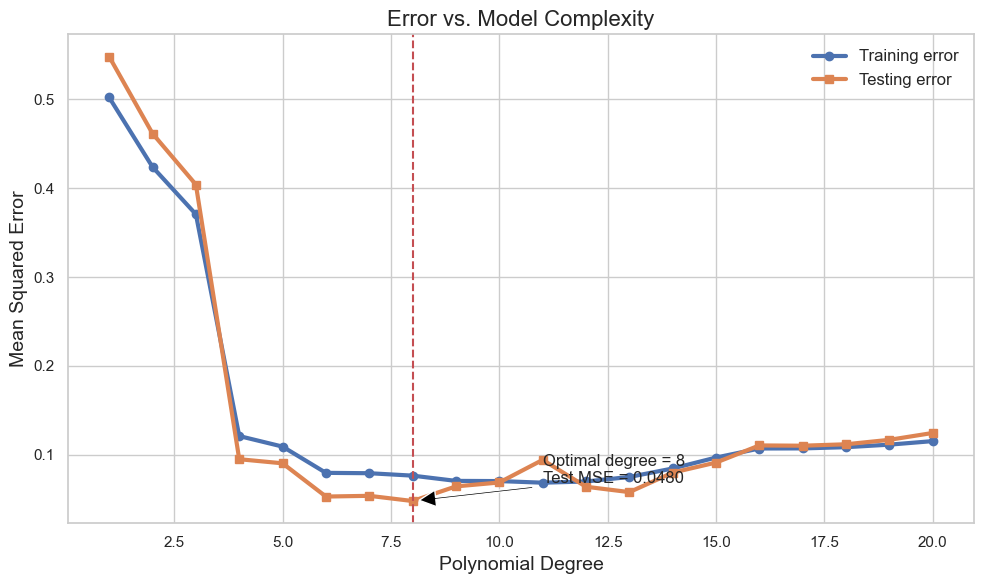

In [11]:
# Try polynomial models with different degrees
degrees = [1, 3, 5, 15]
plt.figure(figsize=(16, 12))

for i, degree in enumerate(degrees):
    # Create and train model
    model = create_poly_model(degree)
    model.fit(X_train, y_train)
    
    # Generate predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_plot_pred = model.predict(X_plot)
    
    # Calculate metrics
    train_error = mean_squared_error(y_train, y_train_pred)
    test_error = mean_squared_error(y_test, y_test_pred)
    
    # Create subplot
    plt.subplot(2, 2, i + 1)
    plt.scatter(X_train, y_train, alpha=0.7, label='Training data', s=30)
    plt.scatter(X_test, y_test, alpha=0.7, label='Test data', color='red', s=30)
    plt.plot(X_plot, y_plot_pred, linewidth=3, label=f'Polynomial (degree={degree})')
    
    plt.title(f'Polynomial Regression (Degree = {degree})', fontsize=14)
    plt.xlabel('X', fontsize=12)
    plt.ylabel('y', fontsize=12)
    plt.legend()
    plt.annotate(f'Training MSE: {train_error:.4f}\nTest MSE: {test_error:.4f}', 
                 xy=(0.05, 0.9), xycoords='axes fraction', 
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
    
plt.tight_layout()
plt.show()

# Compare train and test errors for different polynomial degrees
degrees = list(range(1, 21))
train_errors = []
test_errors = []

for degree in degrees:
    model = create_poly_model(degree)
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_errors.append(mean_squared_error(y_train, y_train_pred))
    test_errors.append(mean_squared_error(y_test, y_test_pred))

# Plot the error curves
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, marker='o', markersize=6, linewidth=3, label='Training error')
plt.plot(degrees, test_errors, marker='s', markersize=6, linewidth=3, label='Testing error')
plt.xlabel('Polynomial Degree', fontsize=14)
plt.ylabel('Mean Squared Error', fontsize=14)
plt.title('Error vs. Model Complexity', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)

# Find the optimal degree
optimal_degree = degrees[np.argmin(test_errors)]
min_test_error = min(test_errors)

plt.axvline(x=optimal_degree, color='r', linestyle='--')
plt.annotate(f'Optimal degree = {optimal_degree}\nTest MSE = {min_test_error:.4f}',
             xy=(optimal_degree, min_test_error),
             xytext=(optimal_degree + 3, min_test_error + 0.02),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5))

plt.tight_layout()
plt.show()

**Finding the Optimal Model**:

From the graphs above, we can observe:

1. **Degree 1 (Linear)**: Underfit - too simple to capture the pattern
2. **Degree 3-5**: Good fit - captures the general pattern without overfitting
3. **Degree 15+**: Overfit - follows the noise in the training data

The optimal model complexity is where the test error is minimized. For complex models (higher degrees), we observe:
- Training error continues to decrease
- Test error initially decreases but then increases (U-shaped curve)
- The point where the test error starts to increase is where overfitting begins

This illustrates the classic bias-variance tradeoff - as we increase model complexity, bias decreases but variance increases.

## 7. Detecting Overfitting with Learning Curves

Learning curves plot the model's performance on training and validation data as a function of the training set size. They're useful for diagnosing bias and variance problems.

<Figure size 1600x1200 with 0 Axes>

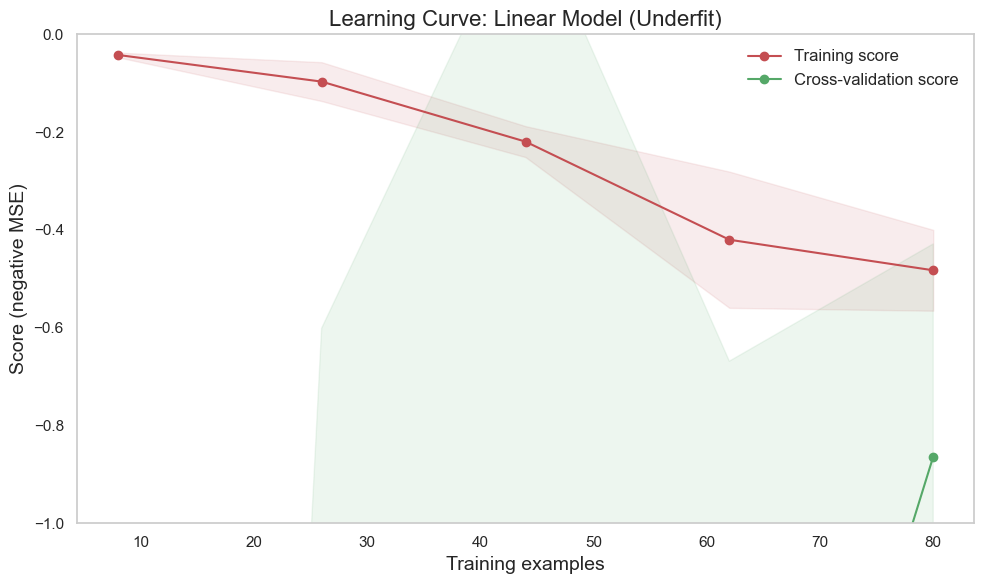

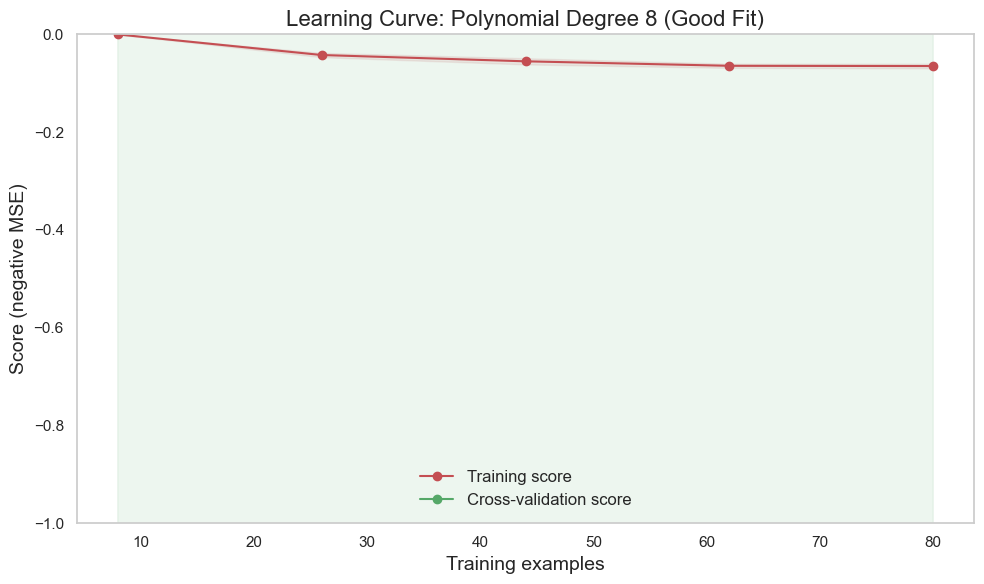

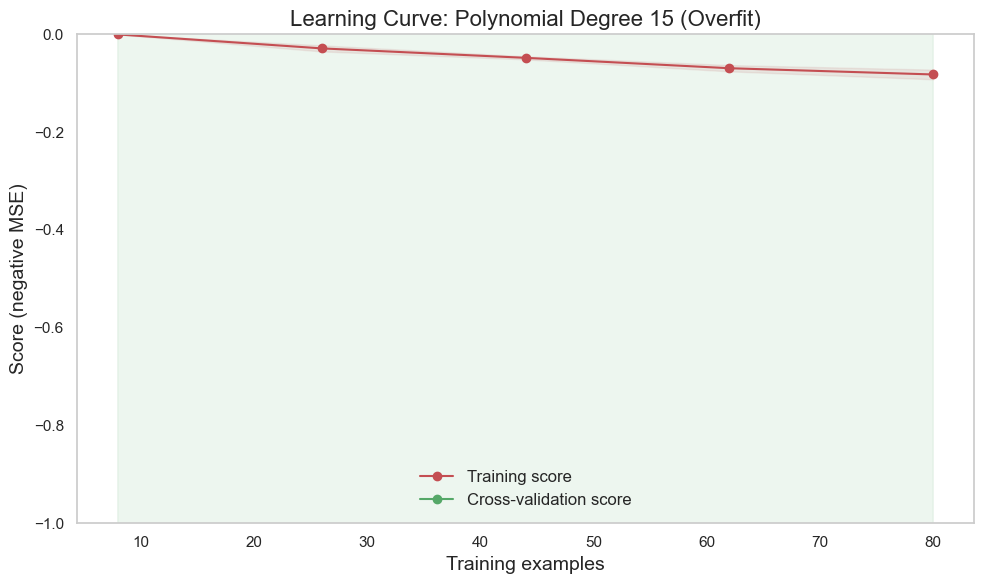

In [12]:
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    plt.figure(figsize=(10, 6))
    plt.title(title, fontsize=16)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples", fontsize=14)
    plt.ylabel("Score (negative MSE)", fontsize=14)
    
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes,
        scoring='neg_mean_squared_error')
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.grid()
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    
    plt.legend(loc="best", fontsize=12)
    return plt

# Plot learning curves for different complexity models
plt.figure(figsize=(16, 12))

# Under-fitting model (Linear)
underfit_model = create_poly_model(1)
plot_learning_curve(underfit_model, "Learning Curve: Linear Model (Underfit)", 
                   X, y, ylim=(-1.0, 0.0), cv=5)
plt.tight_layout()
plt.show()

# Good fit model
optimal_model = create_poly_model(optimal_degree)
plot_learning_curve(optimal_model, f"Learning Curve: Polynomial Degree {optimal_degree} (Good Fit)", 
                   X, y, ylim=(-1.0, 0.0), cv=5)
plt.tight_layout()
plt.show()

# Overfit model
overfit_model = create_poly_model(15)
plot_learning_curve(overfit_model, "Learning Curve: Polynomial Degree 15 (Overfit)", 
                   X, y, ylim=(-1.0, 0.0), cv=5)
plt.tight_layout()
plt.show()

**Interpreting Learning Curves**:

1. **Underfitting (High Bias)**:
   - Both training and validation scores are low (high error)
   - The curves converge as training examples increase
   - Adding more data won't help much - need a more complex model

2. **Good Fit (Balanced)**:
   - Training score is good (low error)
   - Validation score approaches training score as data increases
   - Reasonable gap between training and validation scores

3. **Overfitting (High Variance)**:
   - Large gap between training and validation scores
   - Training score much better than validation score
   - Adding more training data helps reduce the gap

## 8. Techniques to Prevent Overfitting

Now let's explore different techniques to prevent overfitting:

1. Regularization (L1, L2)
2. Simplifying the model
3. Early stopping
4. Cross-validation
5. More training data

In [16]:
# # Create high-degree polynomial features for demonstration
# poly_features = PolynomialFeatures(degree=15)
# X_poly = poly_features.fit_transform(X)
# X_train_poly, X_test_poly, y_train, y_test = train_test_split(X_poly, y, test_size=0.3, random_state=42)

# # Compare different regularization techniques
# models = {
#     "No Regularization": LinearRegression(),
#     "Ridge (L2) - alpha=0.1": Ridge(alpha=0.1),
#     "Ridge (L2) - alpha=1.0": Ridge(alpha=1.0),
#     "Ridge (L2) - alpha=10.0": Ridge(alpha=10.0),
#     "Lasso (L1) - alpha=0.01": Lasso(alpha=0.01),
#     "Lasso (L1) - alpha=0.1": Lasso(alpha=0.1),
# }

# # Plot the results
# plt.figure(figsize=(18, 12))
# X_plot_poly = poly_features.transform(X_plot)

# for i, (name, model) in enumerate(models.items()):
#     model.fit(X_train_poly, y_train)
#     y_train_pred = model.predict(X_train_poly)
#     y_test_pred = model.predict(X_test_poly)
#     y_plot_pred = model.predict(X_plot_poly)
    
#     train_error = mean_squared_error(y_train, y_train_pred)
#     test_error = mean_squared_error(y_test, y_test_pred)
    
#     plt.subplot(2, 3, i+1)
#     plt.scatter(X_train, y_train, alpha=0.7, label='Training data', s=30)
#     plt.scatter(X_test, y_test, alpha=0.7, label='Test data', color='red', s=30)
#     plt.plot(X_plot, y_plot_pred, linewidth=3, label=name)
    
#     plt.title(f'{name}', fontsize=14)
#     plt.xlabel('X', fontsize=12)
#     plt.ylabel('y', fontsize=12)
#     plt.ylim(-2.5, 4.5)
#     plt.legend(loc='upper left', fontsize=10)
#     plt.annotate(f'Training MSE: {train_error:.4f}\nTest MSE: {test_error:.4f}', 
#                  xy=(0.05, 0.85), xycoords='axes fraction', fontsize=10,
#                  bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# plt.tight_layout()
# plt.show()

# # Visualize the effect of regularization on coefficients
# plt.figure(figsize=(12, 6))

# # Get coefficients for different regularization strengths
# alphas = [0, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
# ridge_coefs = []
# lasso_coefs = []

# for alpha in alphas:
#     # Ridge
#     ridge = Ridge(alpha=alpha)
#     ridge.fit(X_train_poly, y_train)
#     ridge_coefs.append(ridge.coef_)
    
#     # Lasso
#     lasso = Lasso(alpha=alpha if alpha > 0 else 0.0000001)  # Lasso needs alpha > 0
#     lasso.fit(X_train_poly, y_train)
#     lasso_coefs.append(lasso.coef_)

# # Plot Ridge coefficients
# plt.subplot(1, 2, 1)
# for i, alpha in enumerate(alphas):
#     plt.plot(range(len(ridge_coefs[i])), ridge_coefs[i], 'o-', label=f'alpha={alpha}')
# plt.title('Ridge Regression Coefficients', fontsize=14)
# plt.xlabel('Coefficient Index', fontsize=12)
# plt.ylabel('Coefficient Value', fontsize=12)
# plt.xscale('log')
# plt.legend(fontsize=9)
# plt.grid(True, alpha=0.3)

# # Plot Lasso coefficients
# plt.subplot(1, 2, 2)
# for i, alpha in enumerate(alphas):
#     plt.plot(range(len(lasso_coefs[i])), lasso_coefs[i], 'o-', label=f'alpha={alpha}')
# plt.title('Lasso Regression Coefficients', fontsize=14)
# plt.xlabel('Coefficient Index', fontsize=12)
# plt.ylabel('Coefficient Value', fontsize=12)
# plt.xscale('log')
# plt.legend(fontsize=9)
# plt.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

```
ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.044e+00, tolerance: 9.234e-03
```

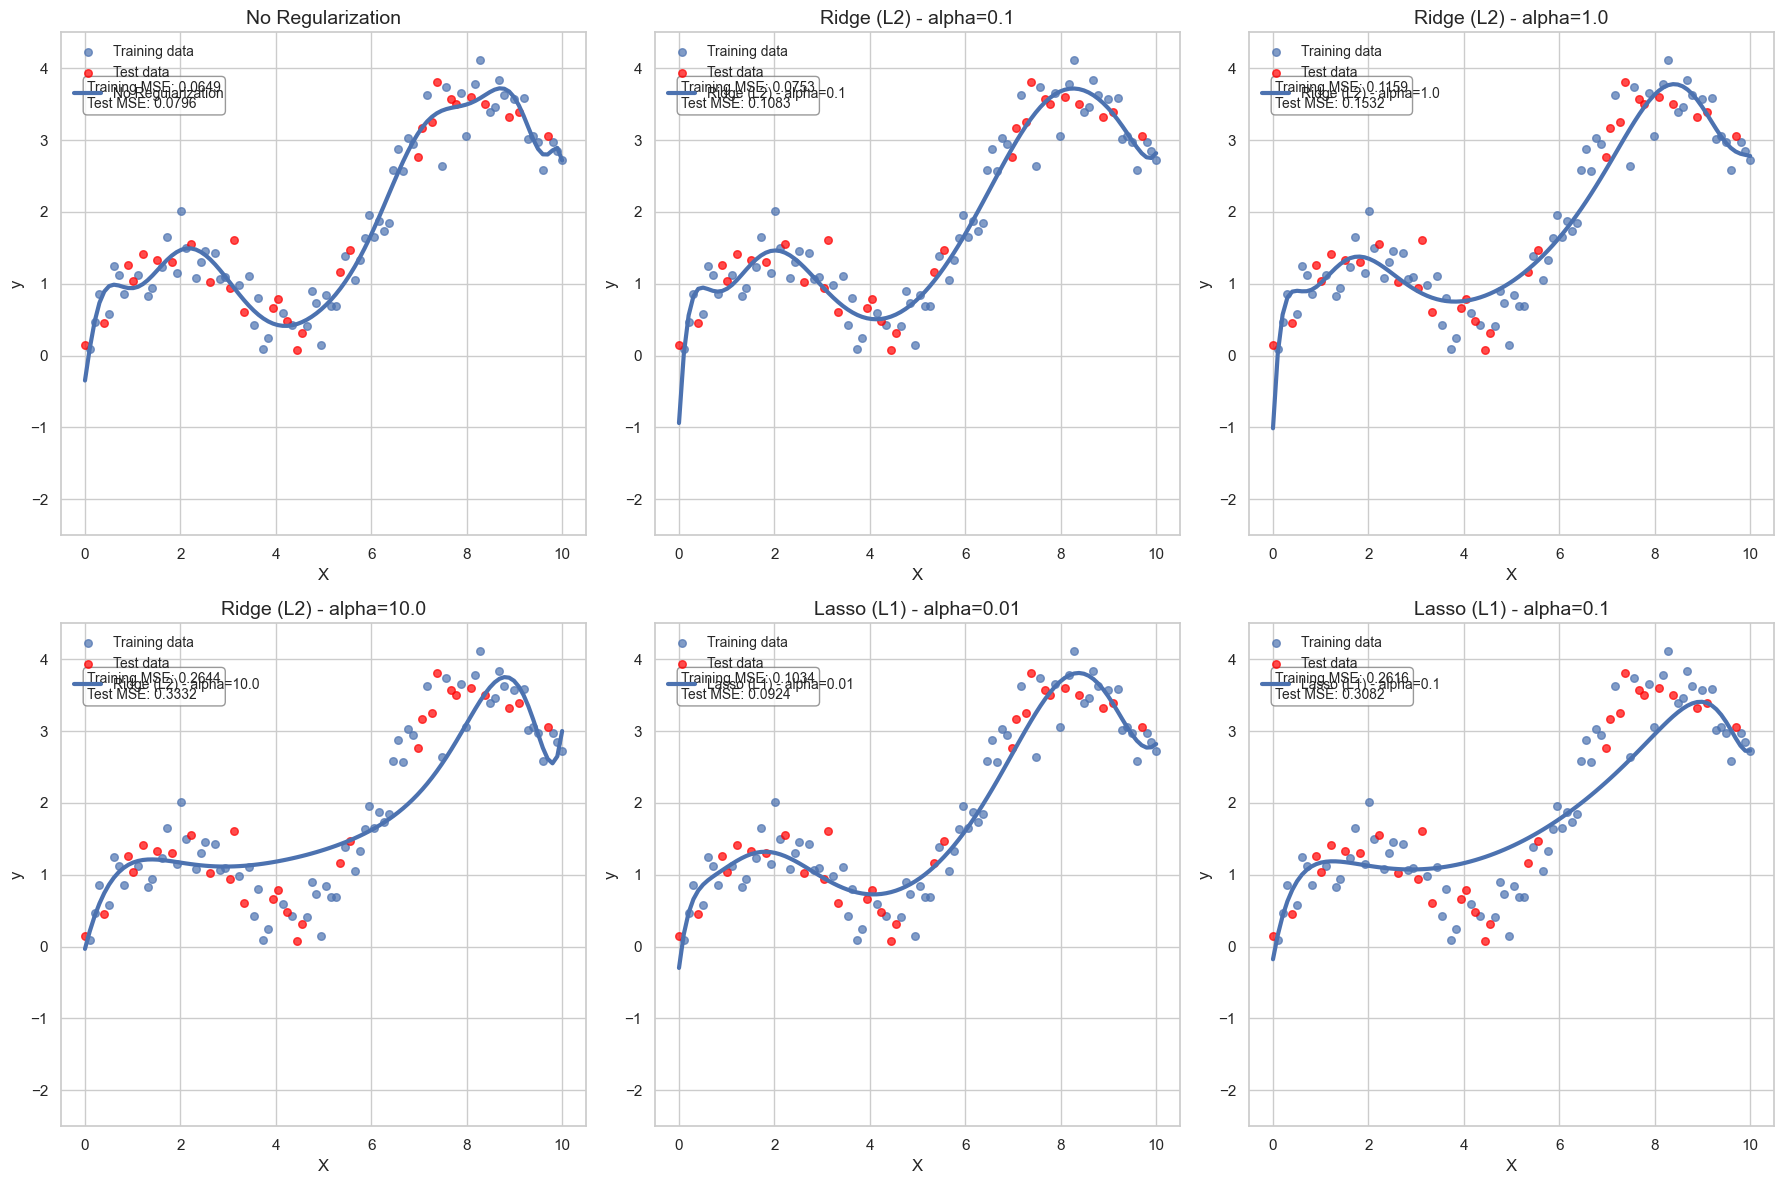

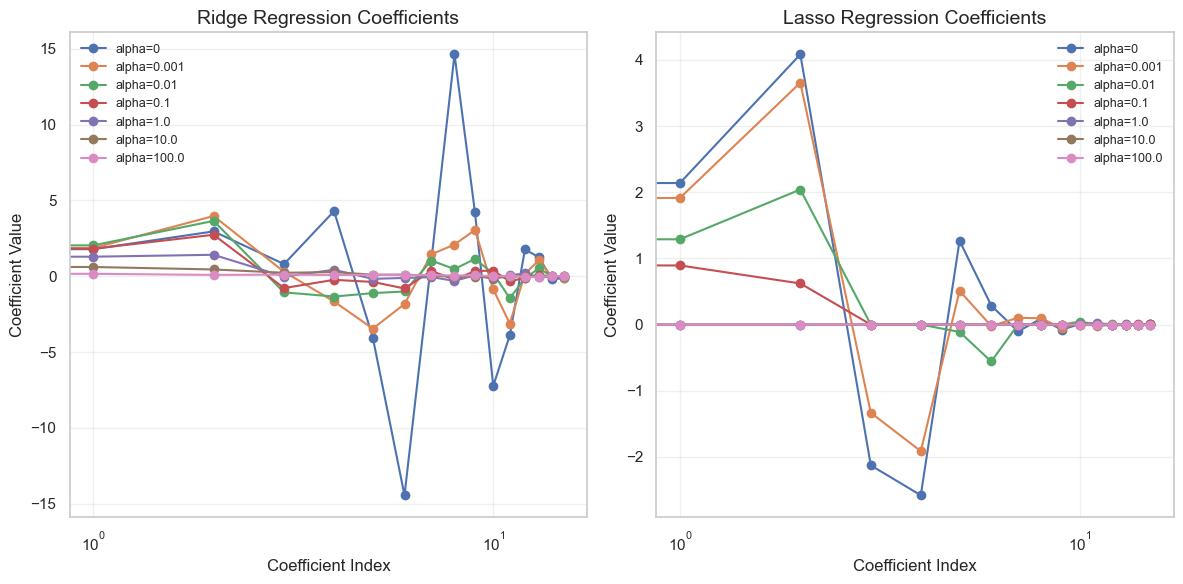

In [17]:
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.exceptions import ConvergenceWarning

# Suppress convergence warnings (optional)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create high-degree polynomial features for demonstration
poly_features = PolynomialFeatures(degree=15)
X_poly = poly_features.fit_transform(X_scaled)
X_train_poly, X_test_poly, y_train, y_test = train_test_split(X_poly, y, test_size=0.3, random_state=42)

# Compare different regularization techniques with increased max_iter for Lasso
models = {
    "No Regularization": LinearRegression(),
    "Ridge (L2) - alpha=0.1": Ridge(alpha=0.1),
    "Ridge (L2) - alpha=1.0": Ridge(alpha=1.0),
    "Ridge (L2) - alpha=10.0": Ridge(alpha=10.0),
    "Lasso (L1) - alpha=0.01": Lasso(alpha=0.01, max_iter=10000),
    "Lasso (L1) - alpha=0.1": Lasso(alpha=0.1, max_iter=10000),
}

# Plot the results
plt.figure(figsize=(18, 12))
X_plot_scaled = scaler.transform(X_plot)  # Ensure X_plot is scaled
X_plot_poly = poly_features.transform(X_plot_scaled)

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train_poly, y_train)
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    y_plot_pred = model.predict(X_plot_poly)
    
    train_error = mean_squared_error(y_train, y_train_pred)
    test_error = mean_squared_error(y_test, y_test_pred)
    
    plt.subplot(2, 3, i+1)
    plt.scatter(X_train, y_train, alpha=0.7, label='Training data', s=30)
    plt.scatter(X_test, y_test, alpha=0.7, label='Test data', color='red', s=30)
    plt.plot(X_plot, y_plot_pred, linewidth=3, label=name)
    
    plt.title(f'{name}', fontsize=14)
    plt.xlabel('X', fontsize=12)
    plt.ylabel('y', fontsize=12)
    plt.ylim(-2.5, 4.5)
    plt.legend(loc='upper left', fontsize=10)
    plt.annotate(f'Training MSE: {train_error:.4f}\nTest MSE: {test_error:.4f}', 
                 xy=(0.05, 0.85), xycoords='axes fraction', fontsize=10,
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.tight_layout()
plt.show()

# Visualize the effect of regularization on coefficients
plt.figure(figsize=(12, 6))

alphas = [0, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
ridge_coefs = []
lasso_coefs = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_poly, y_train)
    ridge_coefs.append(ridge.coef_)
    
    lasso = Lasso(alpha=alpha if alpha > 0 else 1e-7, max_iter=10000)
    lasso.fit(X_train_poly, y_train)
    lasso_coefs.append(lasso.coef_)

plt.subplot(1, 2, 1)
for i, alpha in enumerate(alphas):
    plt.plot(range(len(ridge_coefs[i])), ridge_coefs[i], 'o-', label=f'alpha={alpha}')
plt.title('Ridge Regression Coefficients', fontsize=14)
plt.xlabel('Coefficient Index', fontsize=12)
plt.ylabel('Coefficient Value', fontsize=12)
plt.xscale('log')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for i, alpha in enumerate(alphas):
    plt.plot(range(len(lasso_coefs[i])), lasso_coefs[i], 'o-', label=f'alpha={alpha}')
plt.title('Lasso Regression Coefficients', fontsize=14)
plt.xlabel('Coefficient Index', fontsize=12)
plt.ylabel('Coefficient Value', fontsize=12)
plt.xscale('log')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Regularization Benefits**:

1. **Ridge Regression (L2)**:
   - Shrinks coefficients toward zero but rarely to exactly zero
   - Works well when many features contribute a little bit
   - Helps with multicollinearity
   
2. **Lasso Regression (L1)**:
   - Can drive some coefficients to exactly zero (feature selection)
   - Creates sparse models
   - Good when you suspect many features are irrelevant
   
3. **Effect of Alpha Parameter**:
   - Higher alpha = stronger regularization
   - As alpha increases, model becomes simpler
   - Too high alpha can lead to underfitting
   
Regularization prevents overfitting by penalizing large coefficients, effectively limiting model complexity. This is especially helpful when you have many features relative to the number of samples.

## 9. Cross-validation to Assess Model Performance

K-fold cross-validation helps get a more reliable estimate of a model's performance on unseen data and helps detect overfitting.

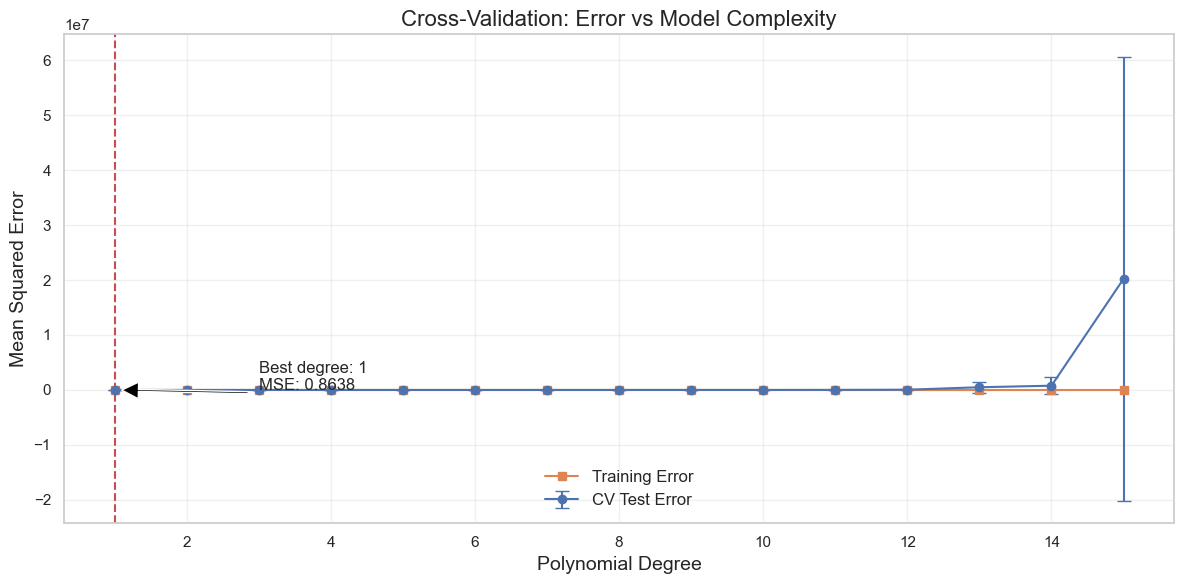

In [18]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.base import clone

# Function to perform k-fold CV for different polynomial degrees
def evaluate_models_with_cv(X, y, max_degree=20, cv=5):
    degrees = list(range(1, max_degree + 1))
    mean_train_scores = []
    mean_test_scores = []
    std_test_scores = []
    
    for degree in degrees:
        model = create_poly_model(degree)
        
        # Cross-validation for test scores
        cv_scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_squared_error')
        mean_test_scores.append(-cv_scores.mean())
        std_test_scores.append(cv_scores.std())
        
        # Train score on all data
        model.fit(X, y)
        y_train_pred = model.predict(X)
        mean_train_scores.append(mean_squared_error(y, y_train_pred))
    
    return degrees, mean_train_scores, mean_test_scores, std_test_scores

# Perform cross-validation for different model complexities
degrees, train_scores, test_scores, test_std = evaluate_models_with_cv(X, y, max_degree=15)

# Plot the results
plt.figure(figsize=(12, 6))
plt.errorbar(degrees, test_scores, yerr=test_std, label='CV Test Error', marker='o', capsize=5)
plt.plot(degrees, train_scores, label='Training Error', marker='s')
plt.xlabel('Polynomial Degree', fontsize=14)
plt.ylabel('Mean Squared Error', fontsize=14)
plt.title('Cross-Validation: Error vs Model Complexity', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# Find the best model
best_degree = degrees[np.argmin(test_scores)]
best_score = min(test_scores)
plt.axvline(x=best_degree, color='r', linestyle='--')
plt.annotate(f'Best degree: {best_degree}\nMSE: {best_score:.4f}', 
             xy=(best_degree, best_score), 
             xytext=(best_degree+2, best_score*1.2),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5))

plt.tight_layout()
plt.show()

**Benefits of Cross-Validation**:

1. **More Reliable Performance Estimation**:
   - K-fold CV uses all data for both training and testing
   - Each data point is used for validation exactly once
   - Reduces variability in performance estimates
   
2. **Better Model Selection**:
   - Helps identify the optimal model complexity
   - Error bars show uncertainty in performance estimates
   - More confident selection of hyperparameters
   
3. **Overfitting Detection**:
   - Large gap between training and CV error indicates overfitting
   - Helps find the complexity level where overfitting begins

Cross-validation is essential for model selection and performance estimation, especially with smaller datasets.

## 10. Real-world Example

Let's apply these concepts to a real-world dataset: the Boston housing dataset, which contains various features of houses and their prices.

In [21]:
# from sklearn.datasets import load_boston
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import train_test_split

# # Load the Boston housing dataset
# try:
#     boston = load_boston()
#     X_boston = boston.data
#     y_boston = boston.target
#     feature_names = boston.feature_names
# except:
#     # Fallback if load_boston() is deprecated
#     from sklearn.datasets import fetch_california_housing
#     housing = fetch_california_housing()
#     X_boston = housing.data
#     y_boston = housing.target
#     feature_names = housing.feature_names
#     print("Using California housing dataset instead of Boston dataset")

# # Scale the features
# scaler = StandardScaler()
# X_boston_scaled = scaler.fit_transform(X_boston)

# # Split the data
# X_train, X_test, y_train, y_test = train_test_split(X_boston_scaled, y_boston, test_size=0.3, random_state=42)

# # Train models with varying complexity
# models = {
#     "Linear Regression (simple)": LinearRegression(),
#     "Ridge Regression (alpha=1.0)": Ridge(alpha=1.0),
#     "Random Forest (5 trees, max_depth=2)": RandomForestRegressor(n_estimators=5, max_depth=2, random_state=42),
#     "Random Forest (100 trees, max_depth=None)": RandomForestRegressor(n_estimators=100, max_depth=None, random_state=42),
#     "SVR (linear kernel)": SVR(kernel='linear', C=1.0),
#     "SVR (rbf kernel, C=100)": SVR(kernel='rbf', C=100, gamma='scale')
# }

# # Train and evaluate each model
# results = {}
# for name, model in models.items():
#     # Train
#     model.fit(X_train, y_train)
    
#     # Predict
#     y_train_pred = model.predict(X_train)
#     y_test_pred = model.predict(X_test)
    
#     # Calculate metrics
#     train_mse = mean_squared_error(y_train, y_train_pred)
#     test_mse = mean_squared_error(y_test, y_test_pred)
#     train_r2 = r2_score(y_train, y_train_pred)
#     test_r2 = r2_score(y_test, y_test_pred)
    
#     results[name] = {
#         'train_mse': train_mse,
#         'test_mse': test_mse,
#         'train_r2': train_r2,
#         'test_r2': test_r2
#     }

# # Display results in a table
# results_df = pd.DataFrame({
#     model_name: {
#         'Training MSE': scores['train_mse'],
#         'Test MSE': scores['test_mse'],
#         'Training R²': scores['train_r2'],
#         'Test R²': scores['test_r2'],
#         'Overfitting (Train MSE / Test MSE)': scores['train_mse'] / scores['test_mse']
#     }
#     for model_name, scores in results.items()
# }).T

# # Plot the results
# plt.figure(figsize=(14, 8))
# bar_width = 0.35
# index = np.arange(len(models))

# plt.subplot(2, 1, 1)
# plt.bar(index - bar_width/2, [results[name]['train_mse'] for name in models.keys()], 
#         bar_width, label='Training MSE', color='skyblue')
# plt.bar(index + bar_width/2, [results[name]['test_mse'] for name in models.keys()], 
#         bar_width, label='Test MSE', color='salmon')
# plt.xticks(index, [name.split('(')[0].strip() for name in models.keys()], rotation=45, ha='right')
# plt.ylabel('Mean Squared Error')
# plt.title('Model Performance Comparison (MSE)')
# plt.legend()
# plt.grid(True, alpha=0.3)

# plt.subplot(2, 1, 2)
# plt.bar(index - bar_width/2, [results[name]['train_r2'] for name in models.keys()], 
#         bar_width, label='Training R²', color='skyblue')
# plt.bar(index + bar_width/2, [results[name]['test_r2'] for name in models.keys()], 
#         bar_width, label='Test R²', color='salmon')
# plt.xticks(index, [name.split('(')[0].strip() for name in models.keys()], rotation=45, ha='right')
# plt.ylabel('R² Score')
# plt.title('Model Performance Comparison (R²)')
# plt.legend()
# plt.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# # Display the results dataframe
# results_df

```
ImportError: 
`load_boston` has been removed from scikit-learn since version 1.2.

The Boston housing prices dataset has an ethical problem: as
investigated in [1], the authors of this dataset engineered a
non-invertible variable "B" assuming that racial self-segregation had a
positive impact on house prices [2]. Furthermore the goal of the
research that led to the creation of this dataset was to study the
impact of air quality but it did not give adequate demonstration of the
validity of this assumption.

The scikit-learn maintainers therefore strongly discourage the use of
this dataset unless the purpose of the code is to study and educate
about ethical issues in data science and machine learning.

In this special case, you can fetch the dataset from the original
source::

    import pandas as pd
    import numpy as np

    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
    target = raw_df.values[1::2, 2]

Alternative datasets include the California housing dataset and the
Ames housing dataset. You can load the datasets as follows::

    from sklearn.datasets import fetch_california_housing
    housing = fetch_california_housing()

for the California housing dataset and::

    from sklearn.datasets import fetch_openml
    housing = fetch_openml(name="house_prices", as_frame=True)

for the Ames housing dataset.

[1] M Carlisle.
"Racist data destruction?"
<https://medium.com/@docintangible/racist-data-destruction-113e3eff54a8>

[2] Harrison Jr, David, and Daniel L. Rubinfeld.
"Hedonic housing prices and the demand for clean air."
Journal of environmental economics and management 5.1 (1978): 81-102.
<https://www.researchgate.net/publication/4974606_Hedonic_housing_prices_and_the_demand_for_clean_air>
```

Using California housing dataset.


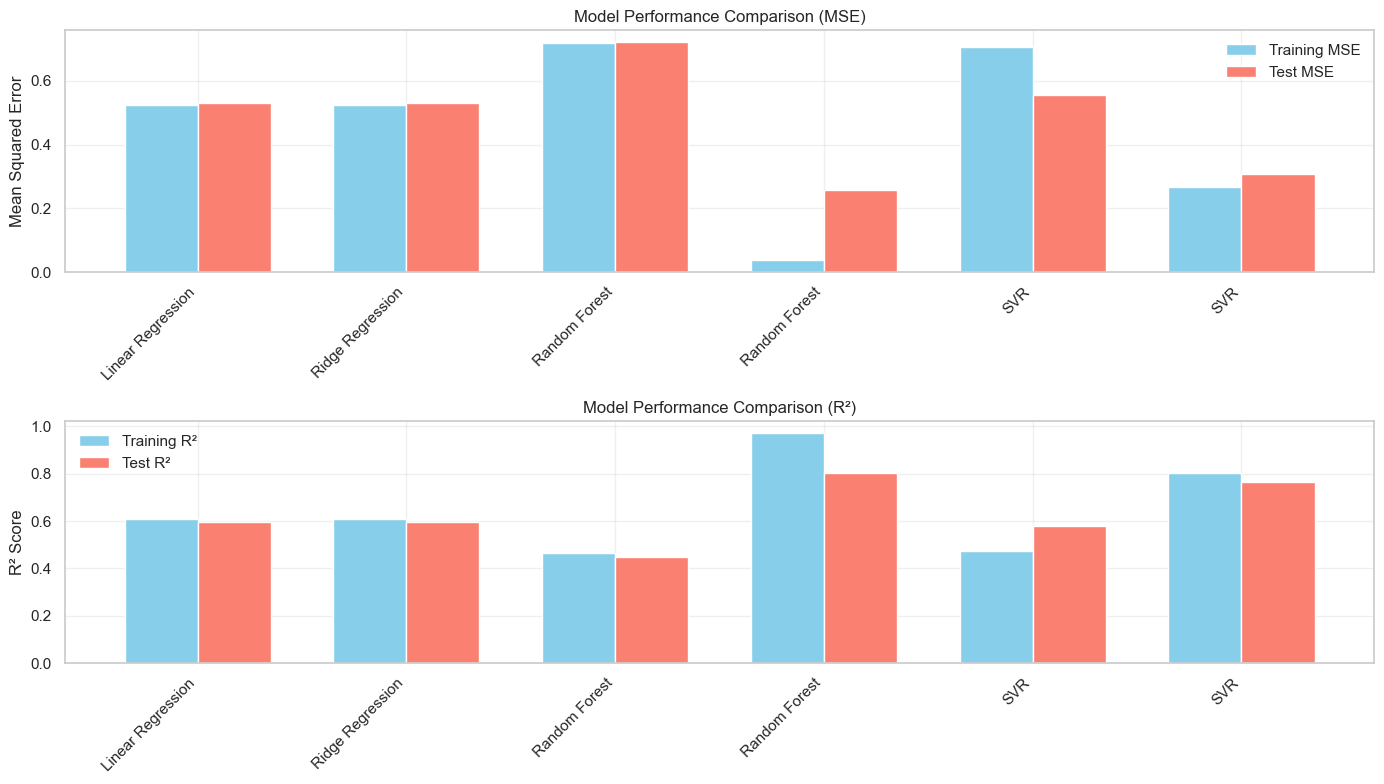

,Training MSE,Test MSE,Training R²,Test R²,Overfitting (Train MSE / Test MSE)
Linear Regression (simple),0.523358,0.530568,0.609346,0.595770,0.986410
Ridge Regression (alpha=1.0),0.523358,0.530542,0.609346,0.595790,0.986458
"Random Forest (5 trees, max_depth=2)",0.719241,0.722141,0.463132,0.449814,0.995984
"Random Forest (100 trees, max_depth=None)",0.036967,0.256400,0.972407,0.804654,0.144176
SVR (linear kernel),0.706902,0.554363,0.472341,0.577641,1.275161
"SVR (rbf kernel, C=100)",0.267021,0.307133,0.800685,0.766001,0.869399


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Load the California housing dataset
housing = fetch_california_housing()
X = housing.data
y = housing.target
feature_names = housing.feature_names
print("Using California housing dataset.")

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Train models with varying complexity
models = {
    "Linear Regression (simple)": LinearRegression(),
    "Ridge Regression (alpha=1.0)": Ridge(alpha=1.0),
    "Random Forest (5 trees, max_depth=2)": RandomForestRegressor(n_estimators=5, max_depth=2, random_state=42),
    "Random Forest (100 trees, max_depth=None)": RandomForestRegressor(n_estimators=100, max_depth=None, random_state=42),
    "SVR (linear kernel)": SVR(kernel='linear', C=1.0),
    "SVR (rbf kernel, C=100)": SVR(kernel='rbf', C=100, gamma='scale')
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    results[name] = {
        'train_mse': train_mse,
        'test_mse': test_mse,
        'train_r2': train_r2,
        'test_r2': test_r2
    }

# Display results in a table
results_df = pd.DataFrame({
    model_name: {
        'Training MSE': scores['train_mse'],
        'Test MSE': scores['test_mse'],
        'Training R²': scores['train_r2'],
        'Test R²': scores['test_r2'],
        'Overfitting (Train MSE / Test MSE)': scores['train_mse'] / scores['test_mse']
    }
    for model_name, scores in results.items()
}).T

# Plot the results
plt.figure(figsize=(14, 8))
bar_width = 0.35
index = np.arange(len(models))

# MSE Plot
plt.subplot(2, 1, 1)
plt.bar(index - bar_width/2, [results[name]['train_mse'] for name in models.keys()], 
        bar_width, label='Training MSE', color='skyblue')
plt.bar(index + bar_width/2, [results[name]['test_mse'] for name in models.keys()], 
        bar_width, label='Test MSE', color='salmon')
plt.xticks(index, [name.split('(')[0].strip() for name in models.keys()], rotation=45, ha='right')
plt.ylabel('Mean Squared Error')
plt.title('Model Performance Comparison (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)

# R² Plot
plt.subplot(2, 1, 2)
plt.bar(index - bar_width/2, [results[name]['train_r2'] for name in models.keys()], 
        bar_width, label='Training R²', color='skyblue')
plt.bar(index + bar_width/2, [results[name]['test_r2'] for name in models.keys()], 
        bar_width, label='Test R²', color='salmon')
plt.xticks(index, [name.split('(')[0].strip() for name in models.keys()], rotation=45, ha='right')
plt.ylabel('R² Score')
plt.title('Model Performance Comparison (R²)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Show results
results_df

**Real-World Example Analysis**:

In this real-world example, we can observe:

1. **Signs of Underfitting**:
   - The linear model and simple SVR show similar performance on both training and test sets
   - These models may be too simple to capture all the patterns in the housing data
   - The R² scores are lower, indicating these models explain less of the variance

2. **Signs of Overfitting**:
   - The complex Random Forest (100 trees, unlimited depth) shows a large gap between training and test performance
   - Near-perfect training R² but lower test R² indicates the model is memorizing training data
   - The ratio between training and test error is high

3. **Well-balanced Models**:
   - Ridge regression shows good balance between training and test performance
   - The simpler Random Forest also performs well without excessive overfitting

This demonstrates how these concepts apply to real datasets, and how regularization (Ridge) and simpler models can help prevent overfitting in practice.

## Summary

In this notebook, we've explored overfitting and underfitting through:

1. **Fundamental Concepts**: Understanding the bias-variance tradeoff

2. **Visualization**: Demonstrating underfitting and overfitting on synthetic datasets

3. **Model Selection**: Finding the optimal model complexity that balances between the two extremes

4. **Diagnostic Tools**: Using learning curves and cross-validation to detect and quantify overfitting

5. **Prevention Techniques**: Implementing regularization (L1/L2) to reduce overfitting

6. **Real-world Application**: Applying these concepts to an actual dataset

**Key Takeaways**:

- Overfitting and underfitting represent opposite ends of the model complexity spectrum
- The goal is to find the optimal level of complexity for your specific dataset
- Regularization techniques are effective tools for controlling model complexity
- Cross-validation is essential for reliable model selection and performance estimation
- Different types of models have different tendencies toward underfitting or overfitting

Understanding and addressing these issues is fundamental to developing machine learning models that perform well on unseen data.